# SPCA Classification - zoo data

This notebook performs supervised PCA with classification on a zoological dataset with 100+ animals. Each animal is annotated with 16 attributes (has hair, has feathers, flies etc.) and belongs to one of 7 classes (mammal, fish, etc.).

The SPCA Classification model jointly learns a 2D latent projection and a linear classifier, balancing reconstruction and classification objectives via the regularization parameter $\lambda$.

In [13]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import matplotlib.pyplot as plt
import numpy as np

from models.spca_classification import SPCA_Classification
from utils import load_zoo_data, scale_features

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data preparation

In [15]:
# Load zoo data
E_raw, C, names, feature_names, class_names = load_zoo_data(device)

# Scale and center features
E = scale_features(E_raw)
E = E - E.mean(dim=0)

## Model training

We train the SPCA Classification model with $\lambda = 0.01$, which puts more weight on the supervised classification error while retaining some unsupervised reconstruction signal.

In [16]:
# Initialize SPCA classification model
model = SPCA_Classification(input_dim=E.shape[1], latent_dim=2, num_classes=len(class_names), lr=0.05).to(device)

# Train model
lam = 0.01  # regularization parameter lambda
steps = 100
model.train(E, C, lam=lam, steps=steps, classifier_epochs=50)

Step 0: loss = 3.1440, classifier loss = 1.8456
Step 10: loss = 2.4852, classifier loss = 1.1828
Step 20: loss = 2.2194, classifier loss = 0.9145
Step 30: loss = 2.0945, classifier loss = 0.7885
Step 40: loss = 2.0190, classifier loss = 0.7121
Step 50: loss = 1.9647, classifier loss = 0.6571
Step 60: loss = 1.9216, classifier loss = 0.6133
Step 70: loss = 1.8856, classifier loss = 0.5767
Step 80: loss = 1.8546, classifier loss = 0.5452
Step 90: loss = 1.8274, classifier loss = 0.5174


## Normalization

Two steps are applied:
1. **Loadings normalization** -- center `L` at zero and scale so the longest loading vector has norm 1 (matching FreeVIZ's `normalize()` step).
2. **Projection normalization** -- scale the projected points `Z` so the maximum absolute coordinate equals 1, confining all data points to `[-1, 1]`.

This makes the resulting vizualization analogous to the Freeviz one, which helps with side-by-side comparison

In [17]:
# Extract latent projections
L = model.L.detach().clone()

# 1. Normalize loadings: center and scale to max norm = 1
L = L - L.mean(dim=0, keepdim=True)
loading_norms = torch.norm(L, dim=1)
L = L / loading_norms.max()

# 2. Project and scale data points to [-1, 1]
Z = E @ L
z_max = torch.abs(Z).max()
Z = Z / z_max

Z_np = Z.cpu().numpy()
C_np = C.cpu().numpy()
L_np = L.cpu().numpy()
print(f"Projection range: [{Z_np.min():.3f}, {Z_np.max():.3f}]")

Projection range: [-0.850, 1.000]


## Vizualization

After training, we project the data onto the learned SPCA axes and overlay the feature loading vectors.

Since SPCA maintains orthonormal columns of `L` rather than constraining the scale of projected points, the data naturally spans a wider range than FreeVIZ. To make the visualization consistent, we apply a normalization step first.

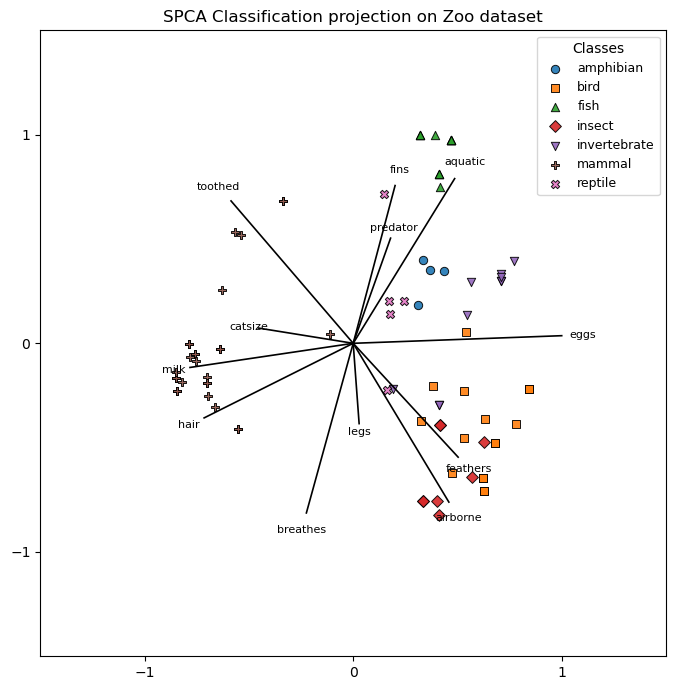

In [18]:
unique_classes = np.unique(C_np)
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>']
cmap = plt.get_cmap('tab10')

plt.figure(figsize=(7, 7))

# Plot points by class
for i, cls in enumerate(unique_classes):
    idx = C_np == cls
    plt.scatter(
        Z_np[idx, 0],
        Z_np[idx, 1],
        color=cmap(i % 10),
        marker=markers[i % len(markers)],
        label=class_names[int(cls)],
        edgecolors='black',
        linewidths=0.7,
        alpha=0.9
    )

# Plot projection vectors (loadings of features) with labels
for i, vec in enumerate(L_np):
    x, y = vec
    length = np.sqrt(x**2 + y**2)
    if length > 0.3:
        plt.plot([0, x], [0, y], linestyle='-', linewidth=1.2, color='black')
        plt.text(
            x * 1.1, y * 1.1,
            feature_names[i],
            fontsize=8,
            ha='center',
            va='center'
        )

# Configure axes
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.xticks([-1, 0, 1])
plt.yticks([-1, 0, 1])
plt.gca().set_aspect('equal', 'box')

plt.legend(title='Classes', loc='upper right', frameon=True, fontsize=9, title_fontsize=10)

plt.title('SPCA Classification projection on Zoo dataset')
plt.tight_layout()
plt.show()